In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,classification_report,confusion_matrix
from sklearn.preprocessing import StandardScaler
print("All are imported")

All are imported


In [3]:
df=pd.read_csv("../data/raw/battery.csv")
df.head(20) #State of Health-soh  Remaining Useful Life-rul

,battery_id,cycle,voltage,temperature,capacity,soh,rul
0,B0005,1,3.532781,32.536891,1.861976,1.000000,167
1,B0005,2,3.542968,32.643595,1.851862,0.994568,166
2,B0005,3,3.553056,32.522526,1.840808,0.988631,165
3,B0005,4,3.545849,32.492083,1.850058,0.993599,164
4,B0005,5,3.544456,32.368612,1.849432,0.993263,163
5,B0005,6,3.555518,32.251242,1.841138,0.988808,162
6,B0005,7,3.550392,32.366192,1.840621,0.988531,161
7,B0005,8,3.557436,32.367489,1.831164,0.983452,160
8,B0005,9,3.553497,32.339648,1.839546,0.987953,159
9,B0005,10,3.557888,32.191180,1.830019,0.982837,158


# DATA UNDERSTANDING

In [4]:

print(df.shape)
print(df.columns)
print(df.info())

(1415, 7)
Index(['battery_id', 'cycle', 'voltage', 'temperature', 'capacity', 'soh',
       'rul'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1415 entries, 0 to 1414
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   battery_id   1415 non-null   object 
 1   cycle        1415 non-null   int64  
 2   voltage      1415 non-null   float64
 3   temperature  1415 non-null   float64
 4   capacity     1415 non-null   float64
 5   soh          1415 non-null   float64
 6   rul          1415 non-null   int64  
dtypes: float64(4), int64(2), object(1)
memory usage: 77.5+ KB
None


In [5]:
df.describe()


,cycle,voltage,temperature,capacity,soh,rul
count,1415.000000,1415.000000,1415.000000,1415.000000,1415.000000,1415.000000
mean,55.389399,3.420612,26.589773,1.501191,0.849014,54.175972
std,42.728497,0.166460,13.196045,0.316995,0.119219,43.709204
min,1.000000,2.530010,7.684550,0.520105,0.604449,0.000000
25%,21.000000,3.387078,9.555186,1.321640,0.750777,16.500000
50%,43.000000,3.452596,31.139259,1.504115,0.850350,43.000000
75%,87.000000,3.507450,32.753400,1.709022,0.961174,86.000000
max,168.000000,3.753027,54.997372,2.498996,1.048527,167.000000


# EDA

c:\Users\nikhi\.anaconda\New folder\nikhil\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


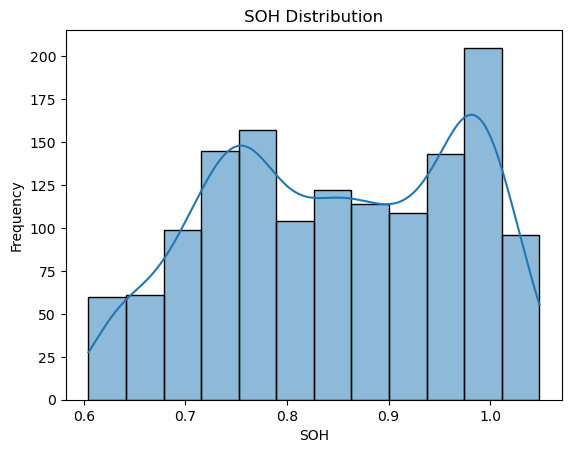

In [6]:
sns.histplot(df['soh'], kde=True)

plt.title("SOH Distribution")
plt.xlabel("SOH")
plt.ylabel("Frequency")

plt.show()

c:\Users\nikhi\.anaconda\New folder\nikhil\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


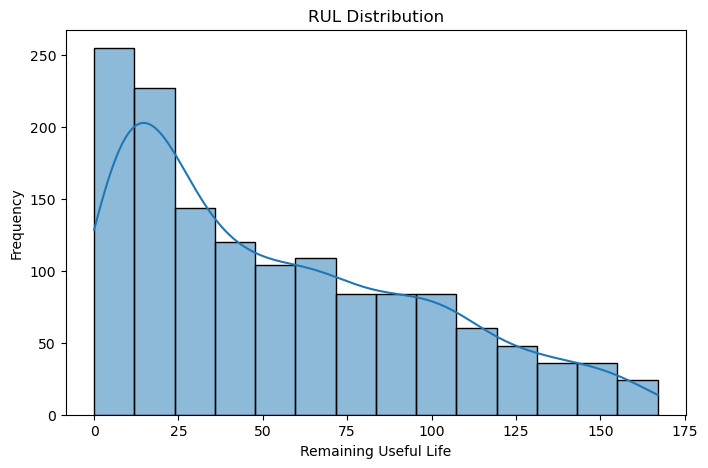

In [7]:
plt.figure(figsize=(8,5))

sns.histplot(df['rul'], kde=True)

plt.title("RUL Distribution")
plt.xlabel("Remaining Useful Life")
plt.ylabel("Frequency")

plt.show()

In [8]:
corr=df[['cycle', 'voltage', 'temperature', 'capacity', 'soh',
       'rul']].corr()
corr

,cycle,voltage,temperature,capacity,soh,rul
cycle,1.000000,0.036271,0.030307,-0.256151,-0.622161,-0.355340
voltage,0.036271,1.000000,0.249777,0.466416,0.257508,0.368511
temperature,0.030307,0.249777,1.000000,0.536293,0.418583,0.174537
capacity,-0.256151,0.466416,0.536293,1.000000,0.643486,0.448028
soh,-0.622161,0.257508,0.418583,0.643486,1.000000,0.332720
rul,-0.355340,0.368511,0.174537,0.448028,0.332720,1.000000


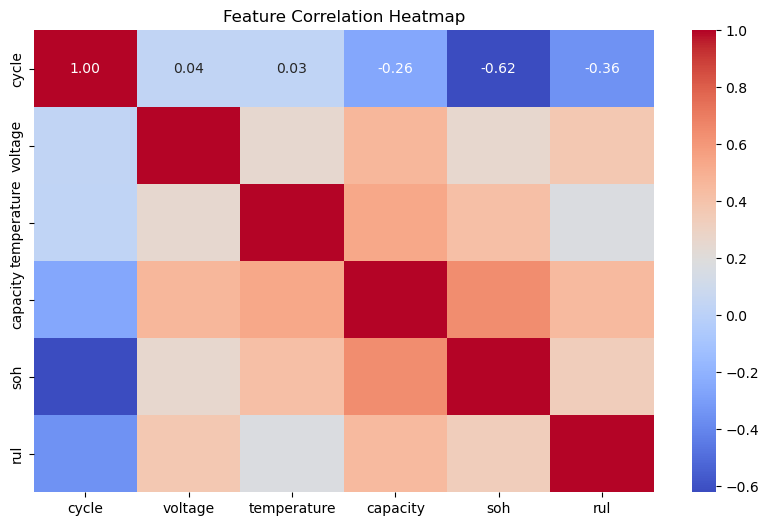

In [9]:
plt.figure(figsize=(10,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Heatmap")

plt.show()

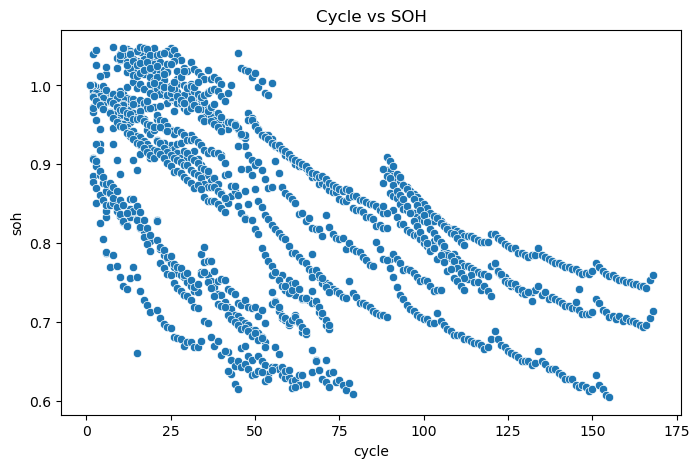

In [10]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='cycle',
    y='soh'
)

plt.title("Cycle vs SOH")
plt.show()

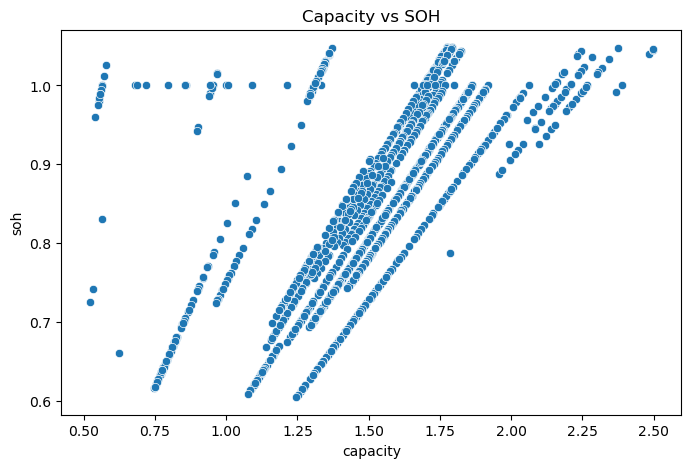

In [11]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='capacity',
    y='soh'
)

plt.title("Capacity vs SOH")
plt.show()

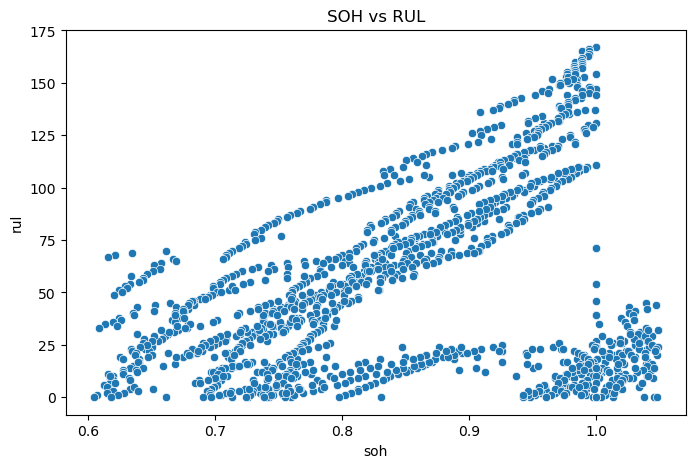

In [12]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='soh',
    y='rul'
)

plt.title("SOH vs RUL")
plt.show()

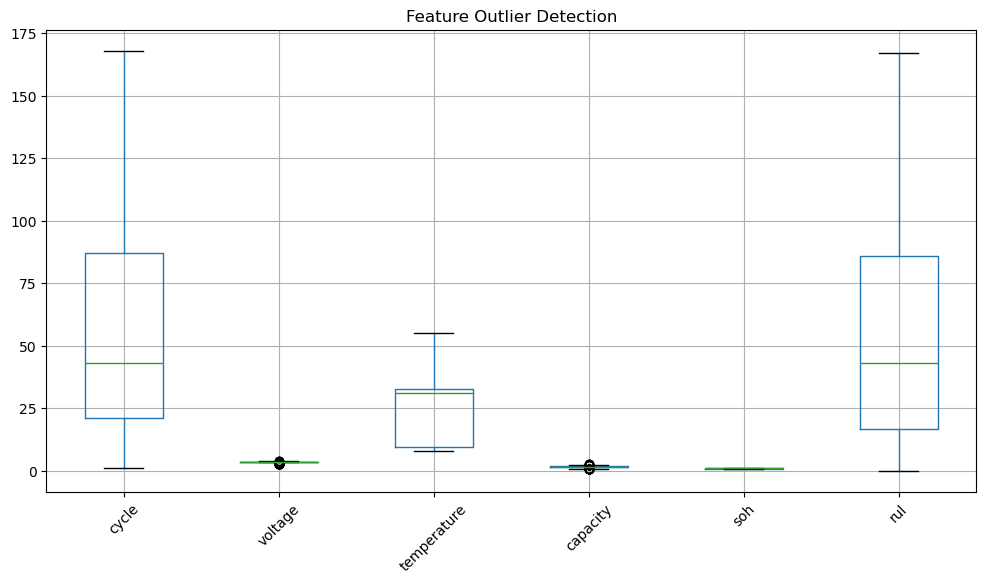

In [13]:
plt.figure(figsize=(12,6))

df.boxplot()

plt.title("Feature Outlier Detection")

plt.xticks(rotation=45)

plt.show()

# DATA PREPROCESSING

In [14]:
df.duplicated().sum()

0

In [15]:
df_clean = df.drop('battery_id', axis=1)

df_clean.head()

,cycle,voltage,temperature,capacity,soh,rul
0,1,3.532781,32.536891,1.861976,1.000000,167
1,2,3.542968,32.643595,1.851862,0.994568,166
2,3,3.553056,32.522526,1.840808,0.988631,165
3,4,3.545849,32.492083,1.850058,0.993599,164
4,5,3.544456,32.368612,1.849432,0.993263,163


In [16]:
df_clean['soh'] = np.clip(
    df_clean['soh'],
    0,
    1
)

In [17]:
df_clean['soh'].describe()

count    1415.000000
mean        0.846860
std         0.116134
min         0.604449
25%         0.750777
50%         0.850350
75%         0.961174
max         1.000000
Name: soh, dtype: float64

In [18]:
X_soh = df_clean[
    [
        'cycle',
        'voltage',
        'temperature',
        'capacity'
    ]
]

In [19]:
y_soh = df_clean['soh']

In [21]:
print(X_soh.head())
print(y_soh.head())

   cycle   voltage  temperature  capacity
0      1  3.532781    32.536891  1.861976
1      2  3.542968    32.643595  1.851862
2      3  3.553056    32.522526  1.840808
3      4  3.545849    32.492083  1.850058
4      5  3.544456    32.368612  1.849432
0    1.000000
1    0.994568
2    0.988631
3    0.993599
4    0.993263
Name: soh, dtype: float64


In [22]:
from sklearn.model_selection import train_test_split

X_train_soh, X_test_soh, y_train_soh, y_test_soh = train_test_split(
    X_soh,
    y_soh,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train_soh.shape)
print("Testing data:", X_test_soh.shape)

Training data: (1132, 4)
Testing data: (283, 4)


In [24]:
from xgboost import XGBRegressor
xgb_soh = XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

In [25]:
xgb_soh.fit(
    X_train_soh,
    y_train_soh
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [26]:
y_pred_soh = xgb_soh.predict(
    X_test_soh
)

In [28]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(
    y_test_soh,
    y_pred_soh
)

rmse = np.sqrt(
    mean_squared_error(
        y_test_soh,
        y_pred_soh
    )
)

r2 = r2_score(
    y_test_soh,
    y_pred_soh
)

print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R2 Score:", round(r2, 2))

MAE: 0.02
RMSE: 0.03
R2 Score: 0.93


In [29]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    'Feature': X_train_soh.columns,
    'Importance': xgb_soh.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance

,Feature,Importance
3,capacity,0.588830
0,cycle,0.217363
2,temperature,0.122388
1,voltage,0.071419


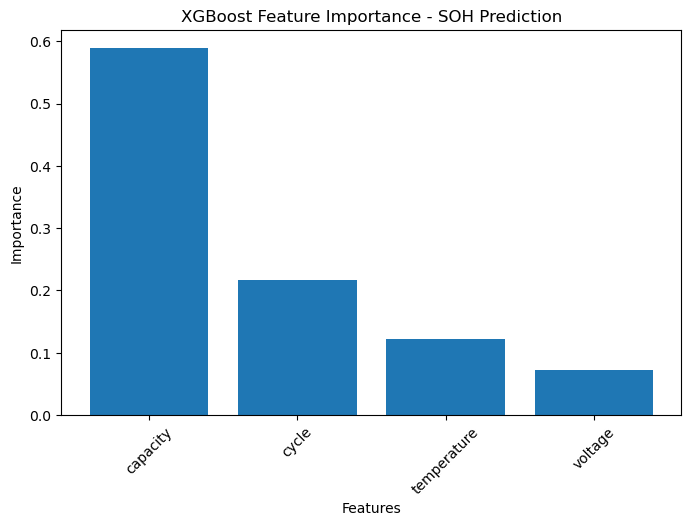

In [30]:
plt.figure(figsize=(8,5))

plt.bar(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.title("XGBoost Feature Importance - SOH Prediction")
plt.xlabel("Features")
plt.ylabel("Importance")

plt.xticks(rotation=45)

plt.show()

In [32]:
soh_predictions = xgb_soh.predict(
    df_clean[
        [
            'cycle',
            'voltage',
            'temperature',
            'capacity'
        ]
    ]
)

In [34]:
df_clean['predicted_soh'] = soh_predictions
df_clean.head()

,cycle,voltage,temperature,capacity,soh,rul,predicted_soh
0,1,3.532781,32.536891,1.861976,1.000000,167,0.992659
1,2,3.542968,32.643595,1.851862,0.994568,166,0.992170
2,3,3.553056,32.522526,1.840808,0.988631,165,0.989515
3,4,3.545849,32.492083,1.850058,0.993599,164,0.989515
4,5,3.544456,32.368612,1.849432,0.993263,163,0.989515


In [35]:
X_rul = df_clean[
    [
        'cycle',
        'voltage',
        'temperature',
        'capacity',
        'predicted_soh'
    ]
]

In [36]:
y_rul = df_clean['rul']

In [38]:
from sklearn.model_selection import train_test_split

X_train_rul, X_test_rul, y_train_rul, y_test_rul = train_test_split(
    X_rul,
    y_rul,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train_rul.shape)
print("Testing data:", X_test_rul.shape)

Training data: (1132, 5)
Testing data: (283, 5)


In [39]:
from xgboost import XGBRegressor

xgb_rul = XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)
xgb_rul.fit(
    X_train_rul,
    y_train_rul
)
y_pred_rul = xgb_rul.predict(
    X_test_rul
)

In [40]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_rul = mean_absolute_error(
    y_test_rul,
    y_pred_rul
)

rmse_rul = np.sqrt(
    mean_squared_error(
        y_test_rul,
        y_pred_rul
    )
)

r2_rul = r2_score(
    y_test_rul,
    y_pred_rul
)

print("RUL Model Performance")
print("--------------------")
print(f"MAE  : {mae_rul:.2f}")
print(f"RMSE : {rmse_rul:.2f}")
print(f"R²   : {r2_rul:.2f}")

RUL Model Performance
--------------------
MAE  : 7.31
RMSE : 9.84
R²   : 0.95


In [41]:
import pandas as pd
import matplotlib.pyplot as plt

rul_feature_importance = pd.DataFrame({
    'Feature': X_train_rul.columns,
    'Importance': xgb_rul.feature_importances_
})

rul_feature_importance = rul_feature_importance.sort_values(
    by='Importance',
    ascending=False
)

rul_feature_importance

,Feature,Importance
1,voltage,0.577331
3,capacity,0.178733
0,cycle,0.100381
4,predicted_soh,0.085488
2,temperature,0.058067


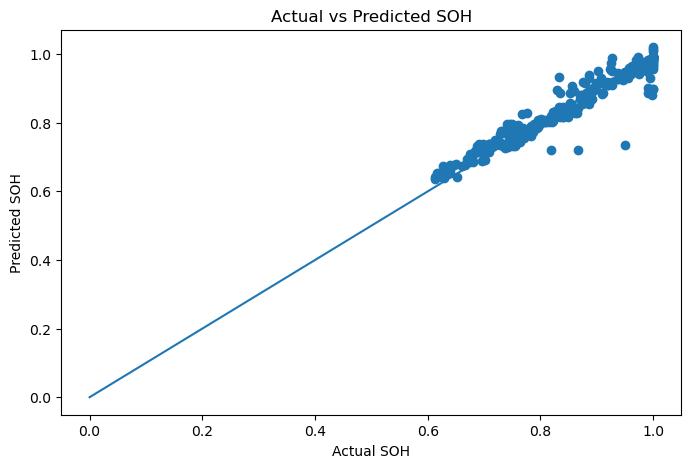

In [44]:
plt.figure(figsize=(8,5))

plt.scatter(
    y_test_soh,
    y_pred_soh
)

plt.plot(
    [0,1],
    [0,1]
)

plt.xlabel("Actual SOH")
plt.ylabel("Predicted SOH")

plt.title("Actual vs Predicted SOH")

plt.show()

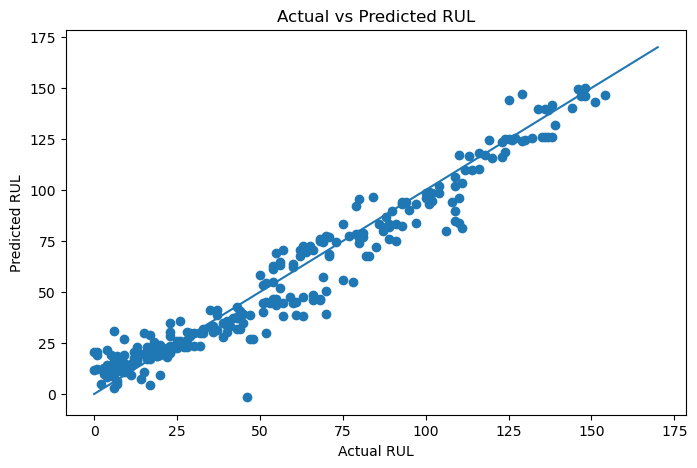

In [45]:
plt.figure(figsize=(8,5))

plt.scatter(
    y_test_rul,
    y_pred_rul
)

plt.plot(
    [0,170],
    [0,170]
)

plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")

plt.title("Actual vs Predicted RUL")

plt.show()

In [46]:
import pickle

In [53]:
with open("../models/soh_model.pkl", "wb") as file:
    pickle.dump(xgb_soh, file)

In [54]:
with open("../models/rul_model.pkl", "wb") as file:
    pickle.dump(xgb_rul, file)

In [55]:
import pickle

with open("../models/soh_model.pkl", "rb") as file:
    loaded_soh_model = pickle.load(file)

with open("../models/rul_model.pkl", "rb") as file:
    loaded_rul_model = pickle.load(file)

print("Models loaded successfully")

Models loaded successfully


In [56]:
import pandas as pd

def predict_battery_health(cycle, voltage, temperature, capacity):

    # Step 1: Prepare input for SOH model
    soh_input = pd.DataFrame({
        'cycle': [cycle],
        'voltage': [voltage],
        'temperature': [temperature],
        'capacity': [capacity]
    })

    # Step 2: Predict SOH
    predicted_soh = loaded_soh_model.predict(
        soh_input
    )[0]


    # Step 3: Prepare input for RUL model
    rul_input = pd.DataFrame({
        'cycle': [cycle],
        'voltage': [voltage],
        'temperature': [temperature],
        'capacity': [capacity],
        'predicted_soh': [predicted_soh]
    })


    # Step 4: Predict RUL
    predicted_rul = loaded_rul_model.predict(
        rul_input
    )[0]


    return predicted_soh, predicted_rul

In [57]:
soh, rul = predict_battery_health(
    cycle=80,
    voltage=3.4,
    temperature=30,
    capacity=1.5
)

print(f"Predicted SOH: {soh*100:.2f}%")
print(f"Predicted RUL: {rul:.0f} cycles")

Predicted SOH: 78.76%
Predicted RUL: 31 cycles
